In [17]:
import os
import pandas as pd
from torchvision.io import read_image
import numpy as np
import torch
from torch import nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
from torchsummary import summary
import torch_directml
from PIL import Image
import time

# Dataset

In [6]:
# The images and masks are in RGB form. To train a semantic segmentation model, each object should be treated as class, e.g. 0,1,2, and not as colors
# Define the color map and corresponding class index
COLOR_MAP = {
    (60, 16, 152): 0,  # Building
    (132, 41, 246): 1,  # Land (unpaved area)
    (110, 193, 228): 2,  # Road
    (254, 221, 58): 3,  # Vegetation
    (226, 169, 41): 4,  # Water
    (155, 155, 155): 5  # Unlabeled
}

# To convert the RGB mask into classes
def rgb_to_class(mask):
    mask = np.array(mask)
    class_mask = np.zeros((mask.shape[0], mask.shape[1]), dtype=np.uint8)

    for rgb, class_idx in COLOR_MAP.items():
        class_mask[(mask == rgb).all(axis=-1)] = class_idx

    return Image.fromarray(class_mask)

#Create a custom dataset class
class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform_image=None, transform_mask=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform_image = transform_image
        self.transform_mask = transform_mask
        self.images = os.listdir(image_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.images[idx])  # If image name is same as the mask name, next line is not needed
        mask_filename = mask_path.replace('image', 'mask').replace('.jpg', '.png')

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_filename).convert("RGB")

        mask = rgb_to_class(mask)


        if self.transform_image:
            image = self.transform_image(image)
        if self.transform_mask:
            mask = self.transform_mask(mask).squeeze().long()

        return image, mask

transform_image = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

transform_mask = transforms.Compose([
    transforms.Resize(size = (256, 256), interpolation = Image.NEAREST),
    transforms.PILToTensor(),
])


image_dir = './data/Kaggle/Multi-Source Satellite Imagery for Segmentation/images'
mask_dir = './data/Kaggle/Multi-Source Satellite Imagery for Segmentation/masks'


dataset = SegmentationDataset(image_dir, mask_dir, transform_image=transform_image, transform_mask=transform_mask)

In [7]:
num_training_samples = len(dataset)
print(f"Number of samples in the dataset: {num_training_samples}")

Number of samples in the dataset: 203


Shape of X [N, C, H, W]: torch.Size([16, 3, 256, 256])
Shape of y: torch.Size([16, 256, 256]) torch.int64


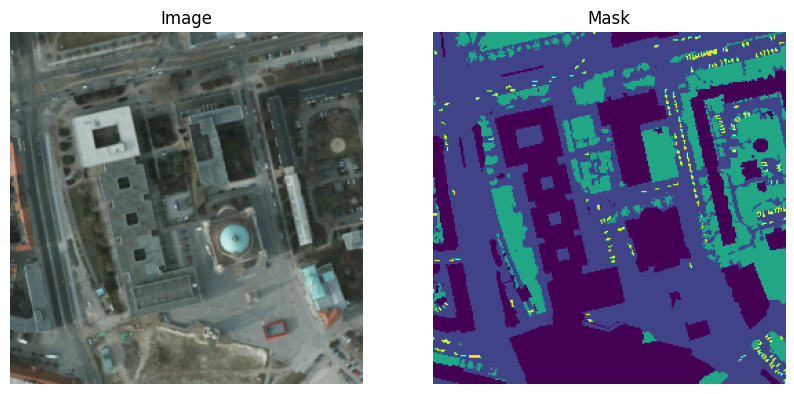

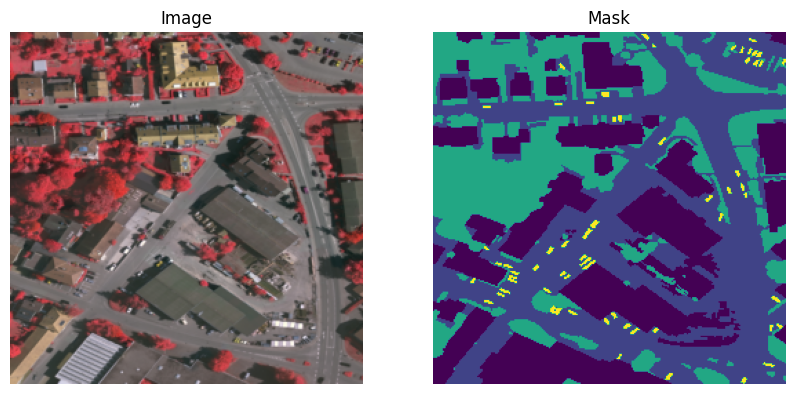

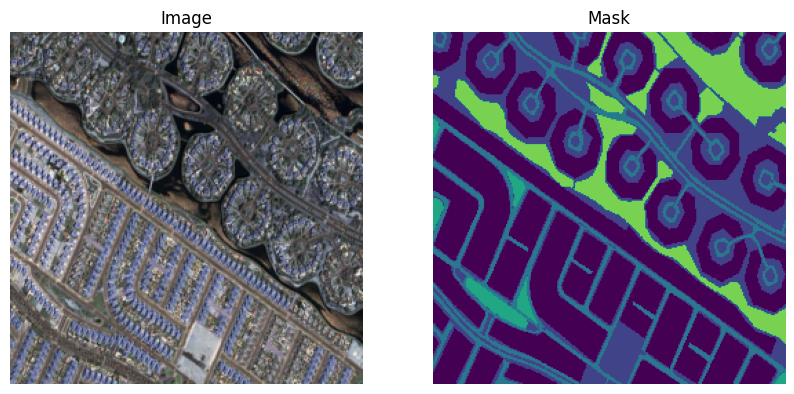

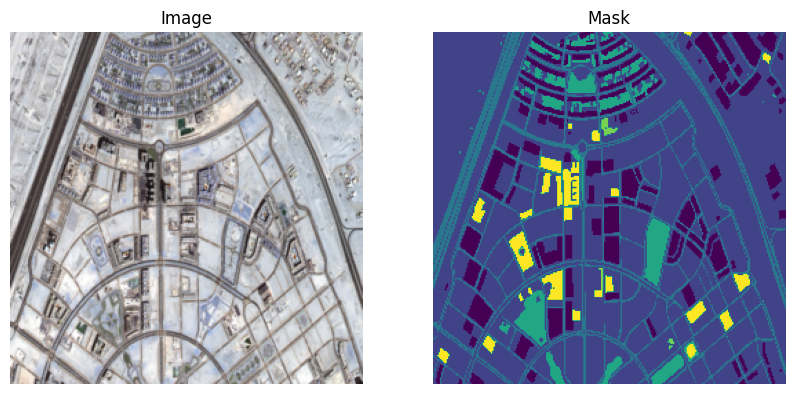

In [10]:
total_size = len(dataset)
train_size = int(0.90 * total_size)  # 90% for train
val_size = int(0.05 * total_size)  # 5% for validation
test_size = total_size - train_size - val_size # remaining for test

# Use random_split to divide the dataset
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

data_loader_train = DataLoader(train_dataset, batch_size=16, shuffle=True)
data_loader_val = DataLoader(val_dataset, batch_size=4, shuffle=False)
data_loader_test = DataLoader(test_dataset, batch_size=4, shuffle=False)

# Display an example
def show_image_mask(image, mask):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    ax1.imshow(image.permute(1, 2, 0))  # Permute to convert (C, H, W) to (H, W, C)
    ax1.set_title('Image')
    ax1.axis('off')

    ax2.imshow(mask.squeeze(), vmin = 0, vmax = 5)
    ax2.set_title('Mask')
    ax2.axis('off')

    plt.show()

# Display examples
for images, masks in data_loader_train:
    print(f"Shape of X [N, C, H, W]: {images.shape}")
    print(f"Shape of y: {masks.shape} {masks.dtype}")

    for i in range(4):
        show_image_mask(images[i], masks[i])
    break

In [19]:
# Get cpu, gpu or mps device for training.
# device = torch_directml.device(torch_directml.default_device()) 
device = "cpu"

# U-net
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1a = nn.Conv2d(3, 32, 3, 1, padding='same')
        self.relu = nn.ReLU(inplace=True)
        self.conv1b = nn.Conv2d(32,32,3,1,padding='same')
        self.pool = nn.MaxPool2d(2,2)

        self.conv2a = nn.Conv2d(32,64,3,1,padding='same')
        self.conv2b = nn.Conv2d(64,64,3,1,padding='same')

        self.conv3a = nn.Conv2d(64,128,3,1,padding='same')
        self.conv3b = nn.Conv2d(128,128,3,1,padding='same')

        self.conv4a = nn.Conv2d(128,256,3,1,padding='same')
        self.conv4b = nn.Conv2d(256,256,3,1,padding='same')

        self.conv5a = nn.Conv2d(256,512,3,1,padding='same')
        self.conv5b = nn.Conv2d(512,512,3,1,padding='same')

        self.conv6a = nn.Conv2d(512,1024,3,1,padding='same')
        self.conv6b = nn.Conv2d(1024,1024,3,1,padding='same')

        self.upconv5 = nn.ConvTranspose2d(1024,512,2,2)

        self.conv5c = nn.Conv2d(1024,512,3,1,padding='same')
        self.conv5d = nn.Conv2d(512,512,3,1,padding='same')

        self.upconv4 = nn.ConvTranspose2d(512,256,2,2)

        self.conv4c = nn.Conv2d(512,256,3,1,padding='same')
        self.conv4d = nn.Conv2d(256,256,3,1,padding='same')

        self.upconv3 = nn.ConvTranspose2d(256,128,2,2)

        self.conv3c = nn.Conv2d(256,128,3,1,padding='same')
        self.conv3d = nn.Conv2d(128,128,3,1,padding='same')

        self.upconv2 = nn.ConvTranspose2d(128,64,2,2)

        self.conv2c = nn.Conv2d(128,64,3,1,padding='same')
        self.conv2d = nn.Conv2d(64,64,3,1,padding='same')

        self.upconv1 = nn.ConvTranspose2d(64,32,2,2)

        self.conv1c = nn.Conv2d(64,32,3,1,padding='same')
        self.conv1d = nn.Conv2d(32,32,3,1,padding='same')

        self.conv1x1 = nn.Conv2d(32,6,1,1,padding='same')

    def forward(self, x):
      x = self.conv1a(x)
      x = self.relu(x)
      x = self.conv1b(x)
      x1 = self.relu(x)
      x = self.pool(x1)
      x = self.conv2a(x)
      x = self.relu(x)
      x = self.conv2b(x)
      x2 = self.relu(x)
      x = self.pool(x2)
      x = self.conv3a(x)
      x = self.relu(x)
      x = self.conv3b(x)
      x3 = self.relu(x)
      x = self.pool(x3)
      x = self.conv4a(x)
      x = self.relu(x)
      x = self.conv4b(x)
      x4 = self.relu(x)
      x = self.pool(x4)
      x = self.conv5a(x)
      x = self.relu(x)
      x = self.conv5b(x)
      x5 = self.relu(x)
      x = self.pool(x5)
      x = self.conv6a(x)
      x = self.relu(x)
      x = self.conv6b(x)
      x6 = self.relu(x)

      x = self.upconv5(x6)
      x = torch.cat([x, x5], dim=1)
      x = self.conv5c(x)
      x = self.relu(x)
      x = self.conv5d(x)
      x = self.relu(x)

      x = self.upconv4(x)
      x = torch.cat([x, x4], dim=1)
      x = self.conv4c(x)
      x = self.relu(x)
      x = self.conv4d(x)
      x = self.relu(x)

      x = self.upconv3(x)
      x = torch.cat([x, x3], dim=1)
      x = self.conv3c(x)
      x = self.relu(x)
      x = self.conv3d(x)
      x = self.relu(x)

      x = self.upconv2(x)
      x = torch.cat([x, x2], dim=1)
      x = self.conv2c(x)
      x = self.relu(x)
      x = self.conv2d(x)
      x = self.relu(x)

      x = self.upconv1(x)
      x = torch.cat([x, x1], dim=1)
      x = self.conv1c(x)
      x = self.relu(x)
      x = self.conv1d(x)
      x = self.relu(x)

      x = self.conv1x1(x)
      return x

model = UNet().to(device)

input = torch.rand(4, 3, 256, 256).to(device) # Shape: [batch_size, channels, depth, height, width]
with torch.no_grad():
    output = model(input)
    print('Output Shape', output.shape)  # Output shape



Output Shape torch.Size([4, 6, 256, 256])


In [20]:
def train_loop(model, dataloader, optimizer, device, criterion):
    model.train()  # Set the model to training mode
    running_loss = 0.0
    total_batches = len(dataloader)
    start_time = time.time()

    for batch, (images, masks) in enumerate(dataloader):
        batch_start_time = time.time()

        images = images.to(device)
        masks = masks.to(device)
        # if torch.isnan(images).any() or torch.isnan(masks).any():
        #     print(f"NaN detected in batch {batch + 1} inputs or masks, skipping this batch.")
        #     break
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, masks)

        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        batch_end_time = time.time()

        print(f' Epoch: {epoch}, Batch {batch + 1}/{total_batches}, Batch Loss: {loss.item():.4f}, Time per batch: {batch_end_time - batch_start_time:.3f} s')

    epoch_end_time = time.time()
    epoch_loss = running_loss / len(dataloader.dataset)
    print(f'Epoch: {epoch}, Total Train Loss: {epoch_loss:.4f}, Time per epoch: {epoch_end_time - start_time:.3f} seconds')

    return epoch_loss

def validate(model, dataloader, device, criterion):
    model.eval()  # Set the model to evaluation mode
    running_loss = 0.0
    with torch.no_grad():  # For evaluation, we don't need gradients
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(dataloader.dataset)
    print(f'Epoch: {epoch}, Total Val Loss: {epoch_loss:.4f}')

    return epoch_loss

In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 10 # Define the number of epochs
train_losses = []
val_losses = []
for epoch in range(num_epochs):
    train_loss = train_loop(model, data_loader_train, optimizer, device, criterion)
    val_loss = validate(model, data_loader_val, device, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

plt.plot(train_losses)
plt.plot(val_losses)

 Epoch: 0, Batch 1/12, Batch Loss: 1.7719, Time per batch: 11.907 s
 Epoch: 0, Batch 2/12, Batch Loss: 1.7800, Time per batch: 8.645 s
 Epoch: 0, Batch 3/12, Batch Loss: 1.7340, Time per batch: 7.352 s
 Epoch: 0, Batch 4/12, Batch Loss: 1.6743, Time per batch: 6.953 s
 Epoch: 0, Batch 5/12, Batch Loss: 1.6466, Time per batch: 7.031 s
 Epoch: 0, Batch 6/12, Batch Loss: 1.5411, Time per batch: 6.916 s


KeyboardInterrupt: 